## 1. Clean Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/interim/vehicles_trimmed.parquet")

# --- Clean and convert types ---
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["odometer"] = pd.to_numeric(df["odometer"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Remove timezone (statsmodels cannot handle tz-aware datetimes)
df["posting_date"] = pd.to_datetime(
    df["posting_date"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

# Clean manufacturer
df["manufacturer"] = df["manufacturer"].astype(str)

# --- Feature engineering ---
df["vehicle_age"] = df["posting_date"].dt.year - df["year"]
df["cost_per_mile"] = df["price"] / df["odometer"]
df["log_price"] = np.log(df["price"])

# Clean model text
df["model"] = (
    df["model"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z0-9 ]", "", regex=True)
    .str.strip()
)

# --- Final cleanup: ensure all regression variables are float64 ---
df["vehicle_age"] = pd.to_numeric(df["vehicle_age"], errors="coerce").astype("float64")
df["odometer"] = df["odometer"].astype("float64")
df["log_price"] = df["log_price"].astype("float64")

# Drop rows with missing regression inputs
df = df.dropna(subset=["log_price", "odometer", "vehicle_age", "price", "year"])

df_reg = df.drop(columns=["posting_date"])

## 2. Check Data Types

In [2]:
# check dataframe types
df.dtypes

price                     int64
year                    float64
manufacturer             object
model                    object
odometer                float64
state                    object
posting_date     datetime64[ns]
vehicle_age             float64
cost_per_mile           float64
log_price               float64
dtype: object

## EDA

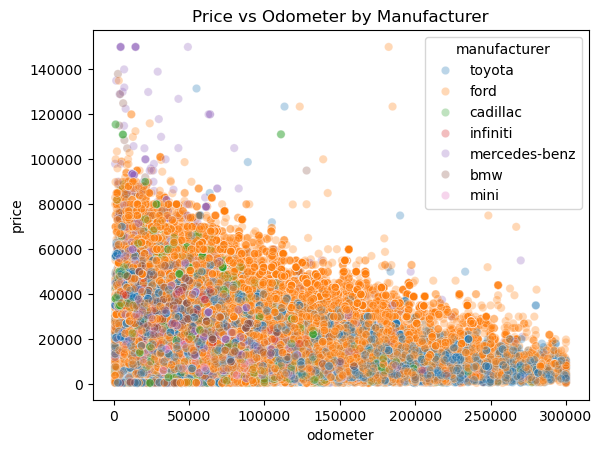

In [3]:
# Price vs. Odometer (raw depreciation curve)
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="odometer", y="price", hue="manufacturer", alpha=0.3)
plt.title("Price vs Odometer by Manufacturer")
plt.show()

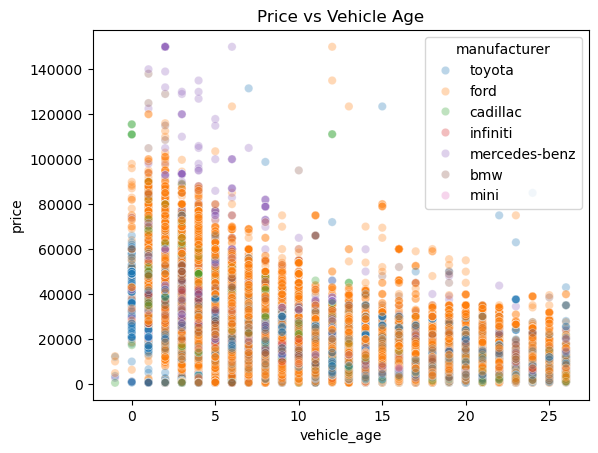

In [4]:
# Price vs Age 
sns.scatterplot(data=df, x="vehicle_age", y="price", hue="manufacturer", alpha=0.3)
plt.title("Price vs Vehicle Age")
plt.show()

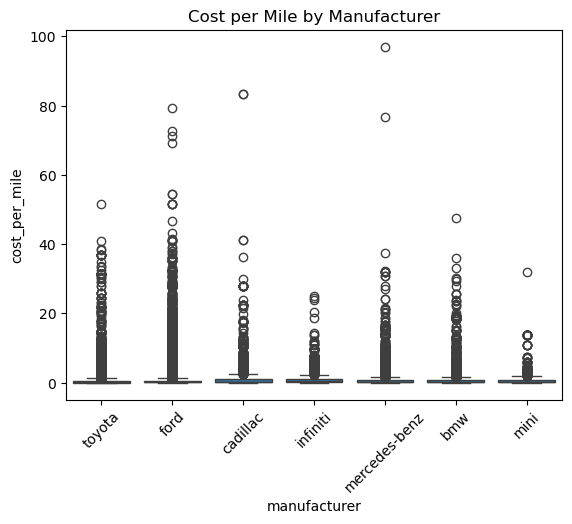

In [5]:
# Cost per mile distribution
sns.boxplot(data=df, x="manufacturer", y="cost_per_mile")
plt.xticks(rotation=45)
plt.title("Cost per Mile by Manufacturer")
plt.show()

## 4. Build depreciation curves

In [6]:
# Log-Linear Regression

import statsmodels.formula.api as smf

model = smf.ols("log_price ~ odometer + C(manufacturer)", data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     9588.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:33:57   Log-Likelihood:            -1.2859e+05
No. Observations:              123451   AIC:                         2.572e+05
Df Residuals:                  123443   BIC:                         2.573e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           10.3597      0.006   1598.479      0.000      10.347      10.372
C(manufacturer)[T.cadillac]         -0.0248      0.011     -2.309      0.021      -0.046      -0.004
C(manufacturer)[T.ford]              0.1525      0.007     22.791      0.000       0.139       0.166
C(manufacturer)[T.infiniti]          0.0215      0.012      1.790      0.073      -0.002       0.045
C(manufacturer)[T.mercedes-benz]     0.0591      0.009      6.353      0.000       0.041       0.077
C(manufacturer)[T.mini]             -0.3712      0.016    -23.382      0.000      -0.402      -0.340
C(manufacturer)[T.toyota]           -0.0057      0.007     -0.784      0.433      -0.020       0.009
odometer                         -8.232e-06   3.25e-08   -253.671      0.000    -8.3e-06   -8.17e-06
==============================================================================
Omnibus:                    29111.493   Durbin-Watson:                   1.657
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           119786.913
Skew:                          -1.117   Prob(JB):                         0.00
Kurtosis:                       7.278   Cond. No.                     1.09e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [7]:
import statsmodels.formula.api as smf

model = smf.ols(
    "log_price ~ odometer + vehicle_age + C(manufacturer)",
    data=df_reg
).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                 1.458e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:33:58   Log-Likelihood:            -1.1433e+05
No. Observations:              123451   AIC:                         2.287e+05
Df Residuals:                  123442   BIC:                         2.288e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           10.6252      0.006   1782.436      0.000      10.614      10.637
C(manufacturer)[T.cadillac]         -0.0454      0.010     -4.746      0.000      -0.064      -0.027
C(manufacturer)[T.ford]              0.0749      0.006     12.535      0.000       0.063       0.087
C(manufacturer)[T.infiniti]         -0.0471      0.011     -4.402      0.000      -0.068      -0.026
C(manufacturer)[T.mercedes-benz]     0.1020      0.008     12.308      0.000       0.086       0.118
C(manufacturer)[T.mini]             -0.3595      0.014    -25.415      0.000      -0.387      -0.332
C(manufacturer)[T.toyota]           -0.0435      0.006     -6.707      0.000      -0.056      -0.031
odometer                         -3.631e-06   3.87e-08    -93.897      0.000   -3.71e-06   -3.56e-06
vehicle_age                         -0.0760      0.000   -179.133      0.000      -0.077      -0.075
==============================================================================
Omnibus:                    40631.548   Durbin-Watson:                   1.663
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           318536.983
Skew:                          -1.370   Prob(JB):                         0.00
Kurtosis:                      10.377   Cond. No.                     1.09e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 5. Optimal replacement mileage

In [8]:
df_sorted = df.sort_values("odometer").copy()
df_sorted.loc[:, "rolling_cpm"] = df_sorted["cost_per_mile"].rolling(500).mean()

df_sorted["rolling_cpm"].describe()

count    122952.000000
mean          0.756728
std           1.919534
min           0.024281
25%           0.097132
50%           0.198787
75%           0.638790
max          23.845214
Name: rolling_cpm, dtype: float64

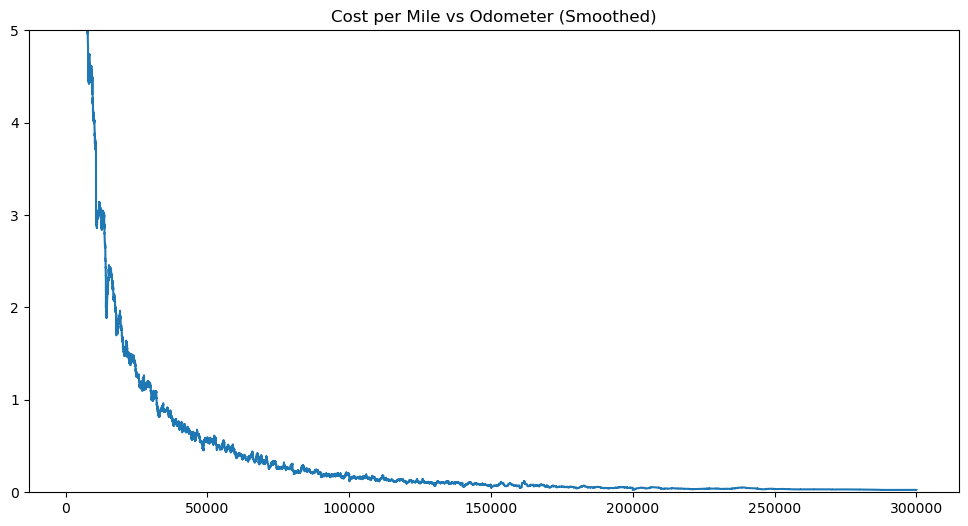

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sorted = df.sort_values("odometer").copy()
df_sorted["rolling_cpm"] = df_sorted["cost_per_mile"].rolling(500).mean()

plot_df = df_sorted[["odometer", "rolling_cpm"]].copy()

plt.figure(figsize=(12,6))
plt.plot(df_sorted["odometer"], df_sorted["rolling_cpm"])
plt.title("Cost per Mile vs Odometer (Smoothed)")
plt.ylim(0, 5)
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sorted = df.sort_values("odometer").copy()
df_sorted["rolling_cpm"] = df_sorted["cost_per_mile"].rolling(500).mean()

plt.figure(figsize=(12,6))
sns.lineplot(data=df_sorted, x="odometer", y="rolling_cpm")
plt.title("Cost per Mile vs Odometer (Smoothed)")
plt.ylim(0, 5)
plt.show()

## 6. Regional pricing analysis

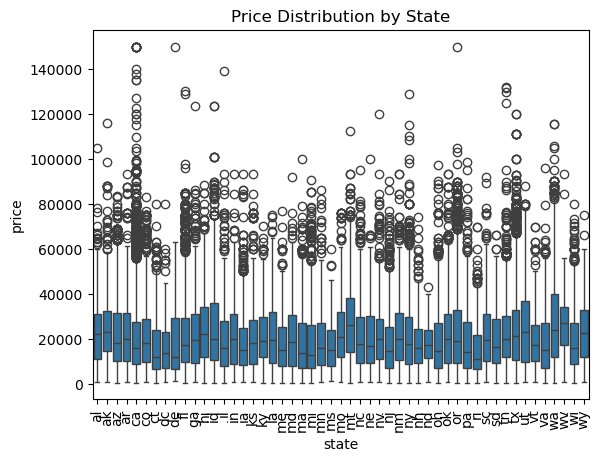

In [6]:
# this is visually useless

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="state", y="price")
plt.xticks(rotation=90)
plt.title("Price Distribution by State")
plt.show()

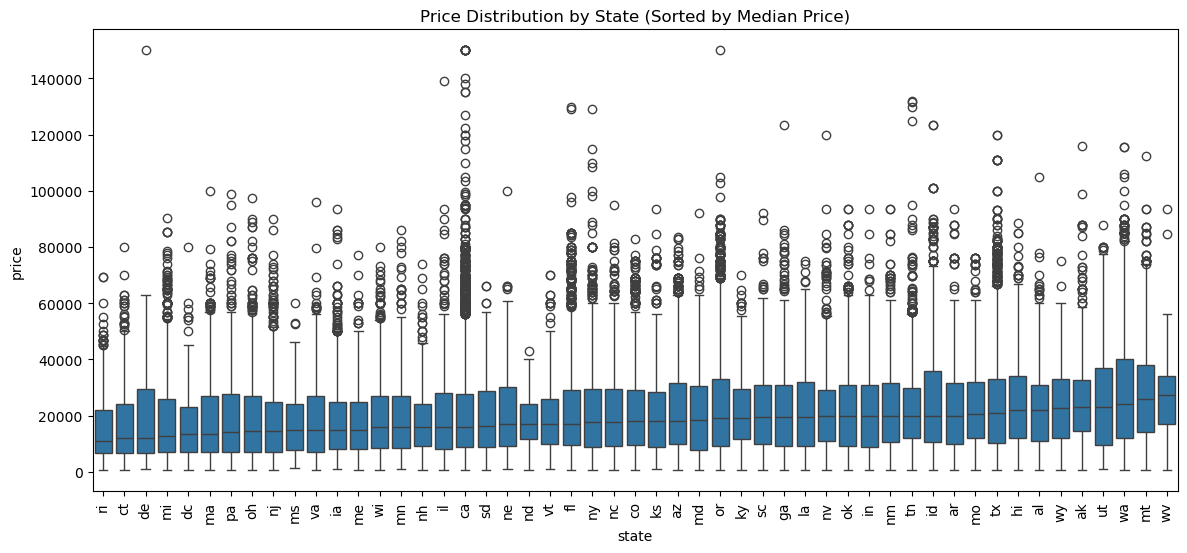

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

order = df.groupby("state")["price"].median().sort_values().index

plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="state", y="price", order=order)
plt.xticks(rotation=90)
plt.title("Price Distribution by State (Sorted by Median Price)")
plt.show()

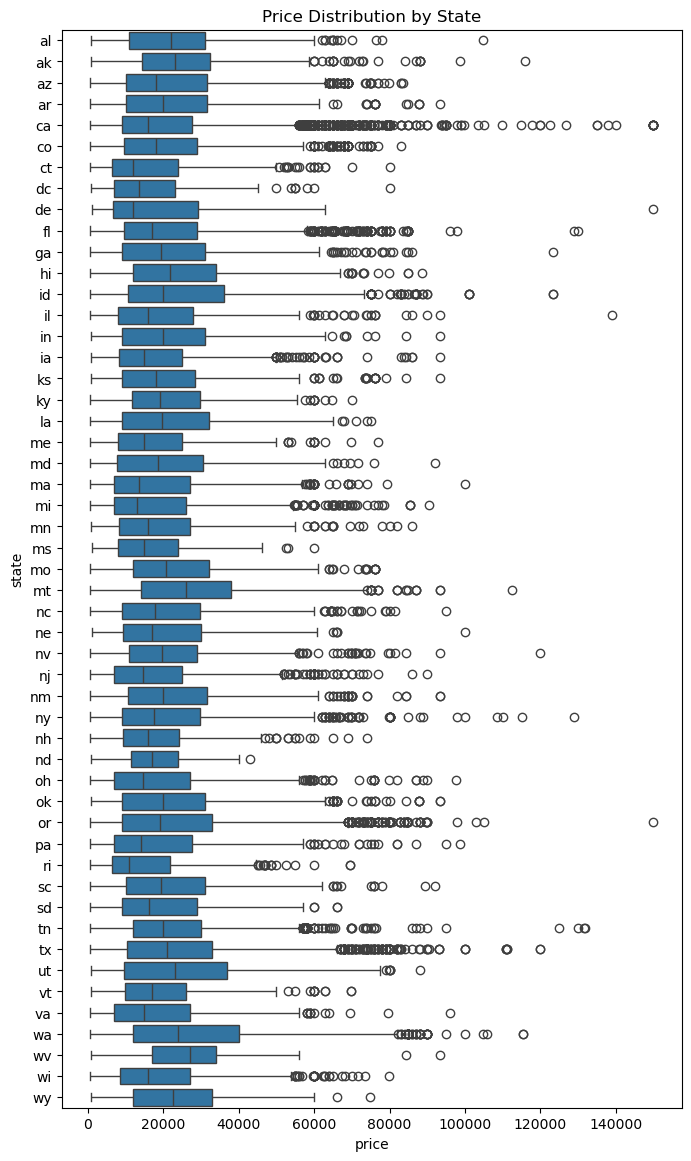

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,14))
sns.boxplot(data=df, y="state", x="price")
plt.title("Price Distribution by State")
plt.show()

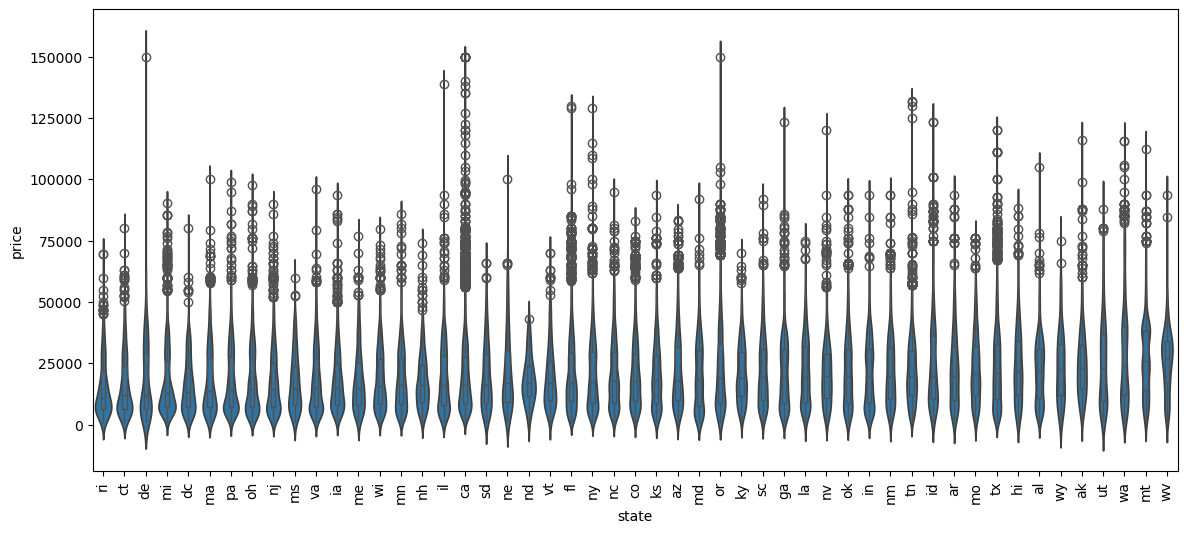

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.violinplot(data=df, x="state", y="price", order=order, inner=None)
sns.boxplot(data=df, x="state", y="price", order=order,
            width=0.2, showcaps=False, boxprops={'facecolor':'none'})
plt.xticks(rotation=90)
plt.show()

In [ ]:
state_avg = df.groupby("state")["price"].mean().sort_values()
state_avg